# Tratamiento de Outliers

Este notebook implementa un pipeline de tratamiento de valores atípicos para un problema de detección de fraude. La estrategia se basa en tres pasos: imputación de valores centinela (`-1`), capping por IQR y escalado robusto, todo ello aprendido exclusivamente sobre el conjunto de entrenamiento para evitar *data leakage*.

## 1. Configuración inicial

### 1.1 Importación de librerías

Se importan las librerías necesarias para manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), preprocesamiento (`RobustScaler`) y partición del dataset (`train_test_split`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split


### 1.2 Carga del dataset

Se carga el CSV con las variables categóricas ya tratadas.

In [2]:
df = pd.read_csv("base-categoricas-tratado.csv")

### 1.3 División train / test (80 – 20)

Se realiza la partición antes de cualquier tratamiento. Todos los parámetros del pipeline se ajustarán **únicamente** sobre `X_train` y se aplicarán después sobre `X_test`, garantizando la ausencia de *data leakage*.

In [3]:
# Separar conjunto de entrenamiento 80-20
X_train, X_test = train_test_split(
    df, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 800000 muestras
Test:  200000 muestras


## Tratamiento de outliers

En este problema no se eliminan observaciones extremas, ya que en detección de fraude los valores atípicos pueden contener información relevante para identificar comportamientos anómalos. Además, la clase fraudulenta está fuertemente desbalanceada, por lo que eliminar filas podría reducir todavía más la información disponible sobre la clase minoritaria.

Se aplica un tratamiento en tres pasos:

1. Los valores `-1` en variables temporales se interpretan como valores desconocidos y se imputan usando la mediana calculada únicamente en el conjunto de entrenamiento.
2. Para las variables continuas con colas largas se aplica capping mediante el criterio IQR, sustituyendo los valores extremos por el límite inferior o superior correspondiente.
3. Se añaden variables binarias indicando si un valor fue imputado o capado, para conservar información sobre la anomalía original.

Todos los parámetros del tratamiento se calculan exclusivamente sobre `X_train` y después se aplican a `X_test`, evitando data leakage.

## 2. Definición de columnas y constantes

Se definen tres grupos de columnas:
- **`sentinel_minus1_cols`**: columnas donde el valor `-1` indica dato desconocido (no un outlier real) y serán imputadas con la mediana de entrenamiento.
- **`cap_cols`**: variables continuas con colas largas sobre las que se aplicará capping por IQR.
- **`cols_no_capadas`**: variables con outliers detectados por IQR pero que no deben caparse por su naturaleza discreta o comercial.

In [7]:
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

# Columnas donde el valor -1 representa ausencia/desconocido,
# no un valor extremo real.
sentinel_minus1_cols: list[str] = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
]

sentinel_minus1_cols = [
    col for col in sentinel_minus1_cols 
    if col in df.columns
]

# Columnas continuas sobre las que sí tiene sentido aplicar capping.
# No incluimos variables binarias, one-hot, ni variables discretas de negocio.
cap_cols: list[str] = [
    "prev_address_months_count",
    "current_address_months_count",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "velocity_24h",
    "bank_branch_count_8w",
    "date_of_birth_distinct_emails_4w",
    "credit_risk_score",
    "session_length_in_minutes",
]

cap_cols = [
    col for col in cap_cols 
    if col in df.columns
]

# Columnas detectadas como "raras" por IQR pero que NO conviene capar directamente.
# customer_age: edades discretizadas y válidas.
# proposed_credit_limit: límites de crédito por tramos comerciales.
# device_distinct_emails_8w / device_fraud_count: variables discretas de baja cardinalidad.
cols_no_capadas: list[str] = [
    "customer_age",
    "proposed_credit_limit",
    "device_distinct_emails_8w",
    "device_fraud_count",
]

print("Columnas con -1 tratadas como desconocido:")
print(sentinel_minus1_cols)

print("\nColumnas con capping IQR:")
print(cap_cols)

print("\nColumnas con outliers detectados pero no capadas:")
print(cols_no_capadas)

Columnas con -1 tratadas como desconocido:
['prev_address_months_count', 'current_address_months_count', 'bank_months_count']

Columnas con capping IQR:
['prev_address_months_count', 'current_address_months_count', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes']

Columnas con outliers detectados pero no capadas:
['customer_age', 'proposed_credit_limit', 'device_distinct_emails_8w', 'device_fraud_count']


## 3. Funciones del pipeline de tratamiento

Se definen cuatro funciones reutilizables que encapsulan la lógica del tratamiento:
- **`fit_sentinel_replacements`**: calcula la mediana de entrenamiento para reemplazar valores `-1`.
- **`apply_sentinel_replacements`**: aplica los reemplazos aprendidos y añade flags binarias de imputación.
- **`fit_iqr_bounds`**: calcula los límites de capping (Q1−k·IQR, Q3+k·IQR) sobre el conjunto de entrenamiento, con soporte para factores personalizados por variable y fallback por cuantiles cuando IQR≈0.
- **`apply_iqr_capping`**: aplica el capping a partir de los límites ya calculados y añade flags binarias de capping.

In [4]:
def fit_sentinel_replacements(
    X: pd.DataFrame,
    columns: list[str],
    sentinel_value: int | float = -1
) -> dict[str, float]:
    """
    Calcula la mediana de entrenamiento para reemplazar valores centinela.
    Solo se usan valores distintos del centinela.
    """
    replacements: dict[str, float] = {}

    for col in columns:
        valid_values = X.loc[X[col] != sentinel_value, col]

        if valid_values.empty:
            replacements[col] = float(X[col].median())
        else:
            replacements[col] = float(valid_values.median())

    return replacements


def apply_sentinel_replacements(
    X: pd.DataFrame,
    replacements: dict[str, float],
    sentinel_value: int | float = -1,
    add_flags: bool = True
) -> pd.DataFrame:
    """
    Reemplaza valores centinela por la mediana aprendida en train.
    Opcionalmente añade una flag indicando si el valor era desconocido.
    """
    X_out = X.copy()

    for col, replacement in replacements.items():
        if col not in X_out.columns:
            continue

        missing_mask = X_out[col] == sentinel_value

        if add_flags:
            X_out[f"{col}_was_missing"] = missing_mask.astype(int)

        X_out[col] = X_out[col].astype(float)
        X_out.loc[missing_mask, col] = replacement

    return X_out


# Factor IQR por variable. Las que no aparecen aquí usan el valor por defecto (3.0).
# - 1.5 para variables donde el capping con 3.0 no tenía efecto real:
#   · prev_address_months_count: IQR=0, caía en fallback con upper_bound=306
#   · credit_risk_score: upper_bound=463, por encima del máximo real de la variable
#   · current_address_months_count: upper_bound=460 meses (~38 años), irreal
CUSTOM_IQR_FACTORS: dict[str, float] = {
    "prev_address_months_count": 1.5,
    "current_address_months_count": 1.5,
    "credit_risk_score": 1.5,
}


def fit_iqr_bounds(
    X: pd.DataFrame,
    columns: list[str],
    iqr_factor: float = 3.0,
    lower_fallback_quantile: float = 0.01,
    upper_fallback_quantile: float = 0.95,
    custom_iqr_factors: dict[str, float] | None = None,
) -> pd.DataFrame:
    """
    Calcula límites de capping usando IQR sobre el conjunto de entrenamiento.

    - iqr_factor=3.0 por defecto: conservador, solo capa extremos severos.
    - custom_iqr_factors permite usar un factor distinto por variable cuando
      el factor global no tiene efecto (IQR muy pequeño o distribución muy ancha).
    - fallback_quantile más ajustado (0.01–0.95) para variables con IQR=0,
      evitando que el upper_bound quede por encima del máximo real.
    """
    if custom_iqr_factors is None:
        custom_iqr_factors = {}

    records: list[dict[str, float | str]] = []

    for col in columns:
        q1 = float(X[col].quantile(0.25))
        q3 = float(X[col].quantile(0.75))
        iqr = q3 - q1
        factor = custom_iqr_factors.get(col, iqr_factor)

        if np.isclose(iqr, 0.0):
            lower_bound = float(X[col].quantile(lower_fallback_quantile))
            upper_bound = float(X[col].quantile(upper_fallback_quantile))
        else:
            lower_bound = q1 - factor * iqr
            upper_bound = q3 + factor * iqr

        records.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": float(iqr),
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        })

    return pd.DataFrame(records)


def apply_iqr_capping(
    X: pd.DataFrame,
    bounds_df: pd.DataFrame,
    add_flags: bool = True
) -> pd.DataFrame:
    """
    Aplica capping a partir de límites ya calculados en entrenamiento.
    Opcionalmente añade una flag indicando si el valor fue capado.
    """
    X_out = X.copy()

    for _, row in bounds_df.iterrows():
        col = str(row["feature"])

        if col not in X_out.columns:
            continue

        lower_bound = float(row["lower_bound"])
        upper_bound = float(row["upper_bound"])

        outlier_mask = (X_out[col] < lower_bound) | (X_out[col] > upper_bound)

        if add_flags:
            X_out[f"{col}_was_capped"] = outlier_mask.astype(int)

        X_out[col] = X_out[col].clip(lower=lower_bound, upper=upper_bound)

    return X_out

## 4. Ejecución del pipeline

Se ejecutan los cuatro pasos en orden:
1. Aprender medianas para valores `-1` en `X_train`.
2. Aplicar la imputación a `X_train` y `X_test`.
3. Calcular los límites IQR sobre el train ya imputado.
4. Aplicar el capping a ambos conjuntos.

Al final se muestran los reemplazos usados, los límites aprendidos y los factores IQR por variable.

In [8]:
# 1. Aprender reemplazos de valores -1 SOLO en train
sentinel_replacements: dict[str, float] = fit_sentinel_replacements(
    X=X_train,
    columns=sentinel_minus1_cols,
    sentinel_value=-1
)

# 2. Aplicar reemplazos a train y test
X_train_sentinel = apply_sentinel_replacements(
    X=X_train,
    replacements=sentinel_replacements,
    sentinel_value=-1,
    add_flags=True
)

X_test_sentinel = apply_sentinel_replacements(
    X=X_test,
    replacements=sentinel_replacements,
    sentinel_value=-1,
    add_flags=True
)

# 3. Aprender límites IQR SOLO en train ya corregido
bounds_df = fit_iqr_bounds(
    X=X_train_sentinel,
    columns=cap_cols,
    iqr_factor=3.0,
    custom_iqr_factors=CUSTOM_IQR_FACTORS,  # factor 1.5 para las 3 variables problemáticas
)

# 4. Aplicar capping a train y test
X_train_out = apply_iqr_capping(
    X=X_train_sentinel,
    bounds_df=bounds_df,
    add_flags=True
)

X_test_out = apply_iqr_capping(
    X=X_test_sentinel,
    bounds_df=bounds_df,
    add_flags=True
)

print("Shape original train:", X_train.shape)
print("Shape tratado train: ", X_train_out.shape)
print("Shape original test: ", X_test.shape)
print("Shape tratado test:  ", X_test_out.shape)

print("\nReemplazos usados para valores -1:")
display(pd.DataFrame.from_dict(
    sentinel_replacements,
    orient="index",
    columns=["replacement_median_train"]
))

print("\nLímites aprendidos para capping:")
display(bounds_df.round(3))

print("\nFactores IQR aplicados por variable:")
display(pd.DataFrame([
    {
        "feature": row["feature"],
        "factor_usado": CUSTOM_IQR_FACTORS.get(str(row["feature"]), 3.0),
        "lower_bound": round(row["lower_bound"], 3),
        "upper_bound": round(row["upper_bound"], 3),
    }
    for _, row in bounds_df.iterrows()
]))

Shape original train: (800000, 47)
Shape tratado train:  (800000, 61)
Shape original test:  (200000, 47)
Shape tratado test:   (200000, 61)

Reemplazos usados para valores -1:


,replacement_median_train
prev_address_months_count,34.0
current_address_months_count,53.0
bank_months_count,15.0



Límites aprendidos para capping:


,feature,q1,q3,iqr,lower_bound,upper_bound
0,prev_address_months_count,34.000,34.000,0.000,10.000,98.000
1,current_address_months_count,20.000,130.000,110.000,-145.000,295.000
2,days_since_request,0.007,0.026,0.019,-0.050,0.084
3,intended_balcon_amount,-1.181,4.984,6.166,-19.679,23.481
4,zip_count_4w,894.000,1943.000,1049.000,-2253.000,5090.000
5,velocity_6h,3435.963,7681.772,4245.809,-9301.465,20419.200
6,velocity_24h,3592.988,5750.629,2157.641,-2879.935,12223.552
7,bank_branch_count_8w,1.000,25.000,24.000,-71.000,97.000
8,date_of_birth_distinct_emails_4w,6.000,13.000,7.000,-15.000,34.000
9,credit_risk_score,83.000,178.000,95.000,-59.500,320.500



Factores IQR aplicados por variable:


,feature,factor_usado,lower_bound,upper_bound
0,prev_address_months_count,1.5,10.000,98.000
1,current_address_months_count,1.5,-145.000,295.000
2,days_since_request,3.0,-0.050,0.084
3,intended_balcon_amount,3.0,-19.679,23.481
4,zip_count_4w,3.0,-2253.000,5090.000
5,velocity_6h,3.0,-9301.465,20419.200
6,velocity_24h,3.0,-2879.935,12223.552
7,bank_branch_count_8w,3.0,-71.000,97.000
8,date_of_birth_distinct_emails_4w,3.0,-15.000,34.000
9,credit_risk_score,1.5,-59.500,320.500


## 5. Resumen del tratamiento aplicado

La función `build_treatment_summary` construye una tabla que indica, para cada variable tratada, cuántos valores fueron imputados o capados en `X_train` y `X_test` (en valor absoluto y en porcentaje). Esto permite verificar el impacto real del tratamiento sobre los datos.

In [9]:
def build_treatment_summary(
    X_train_treated: pd.DataFrame,
    X_test_treated: pd.DataFrame,
    sentinel_cols: list[str],
    capped_cols: list[str]
) -> pd.DataFrame:
    """
    Resume cuántos valores han sido imputados o capados en train y test.
    """
    rows: list[dict[str, int | float | str]] = []

    for col in sentinel_cols:
        flag_col = f"{col}_was_missing"

        if flag_col in X_train_treated.columns:
            train_count = int(X_train_treated[flag_col].sum())
            test_count = int(X_test_treated[flag_col].sum())

            rows.append({
                "feature": col,
                "tratamiento": "reemplazo_-1",
                "train_count": train_count,
                "train_%": train_count / len(X_train_treated) * 100,
                "test_count": test_count,
                "test_%": test_count / len(X_test_treated) * 100,
            })

    for col in capped_cols:
        flag_col = f"{col}_was_capped"

        if flag_col in X_train_treated.columns:
            train_count = int(X_train_treated[flag_col].sum())
            test_count = int(X_test_treated[flag_col].sum())

            rows.append({
                "feature": col,
                "tratamiento": "capping_IQR",
                "train_count": train_count,
                "train_%": train_count / len(X_train_treated) * 100,
                "test_count": test_count,
                "test_%": test_count / len(X_test_treated) * 100,
            })

    return pd.DataFrame(rows).sort_values(
        by=["tratamiento", "train_%"],
        ascending=[True, False]
    )


treatment_summary = build_treatment_summary(
    X_train_treated=X_train_out,
    X_test_treated=X_test_out,
    sentinel_cols=sentinel_minus1_cols,
    capped_cols=cap_cols
)

display(treatment_summary.round(3))

,feature,tratamiento,train_count,train_%,test_count,test_%
6,intended_balcon_amount,capping_IQR,140928,17.616,35318,17.659
10,bank_branch_count_8w,capping_IQR,138438,17.305,34272,17.136
5,days_since_request,capping_IQR,74881,9.360,18814,9.407
3,prev_address_months_count,capping_IQR,45394,5.674,11270,5.635
4,current_address_months_count,capping_IQR,33143,4.143,8350,4.175
13,session_length_in_minutes,capping_IQR,27799,3.475,6897,3.448
12,credit_risk_score,capping_IQR,6996,0.874,1733,0.866
7,zip_count_4w,capping_IQR,6702,0.838,1607,0.804
11,date_of_birth_distinct_emails_4w,capping_IQR,75,0.009,22,0.011
8,velocity_6h,capping_IQR,0,0.000,0,0.000


## 6. Visualización: boxplots antes y después del capping

La función `visualizar_capping_antes_despues` genera boxplots comparativos (antes / después del tratamiento) para las variables continuas capadas. Se trabaja sobre una muestra de hasta 50 000 filas del conjunto de entrenamiento para agilizar el renderizado. El gráfico se guarda automáticamente como `visualizacion_capping_antes_despues.png`.

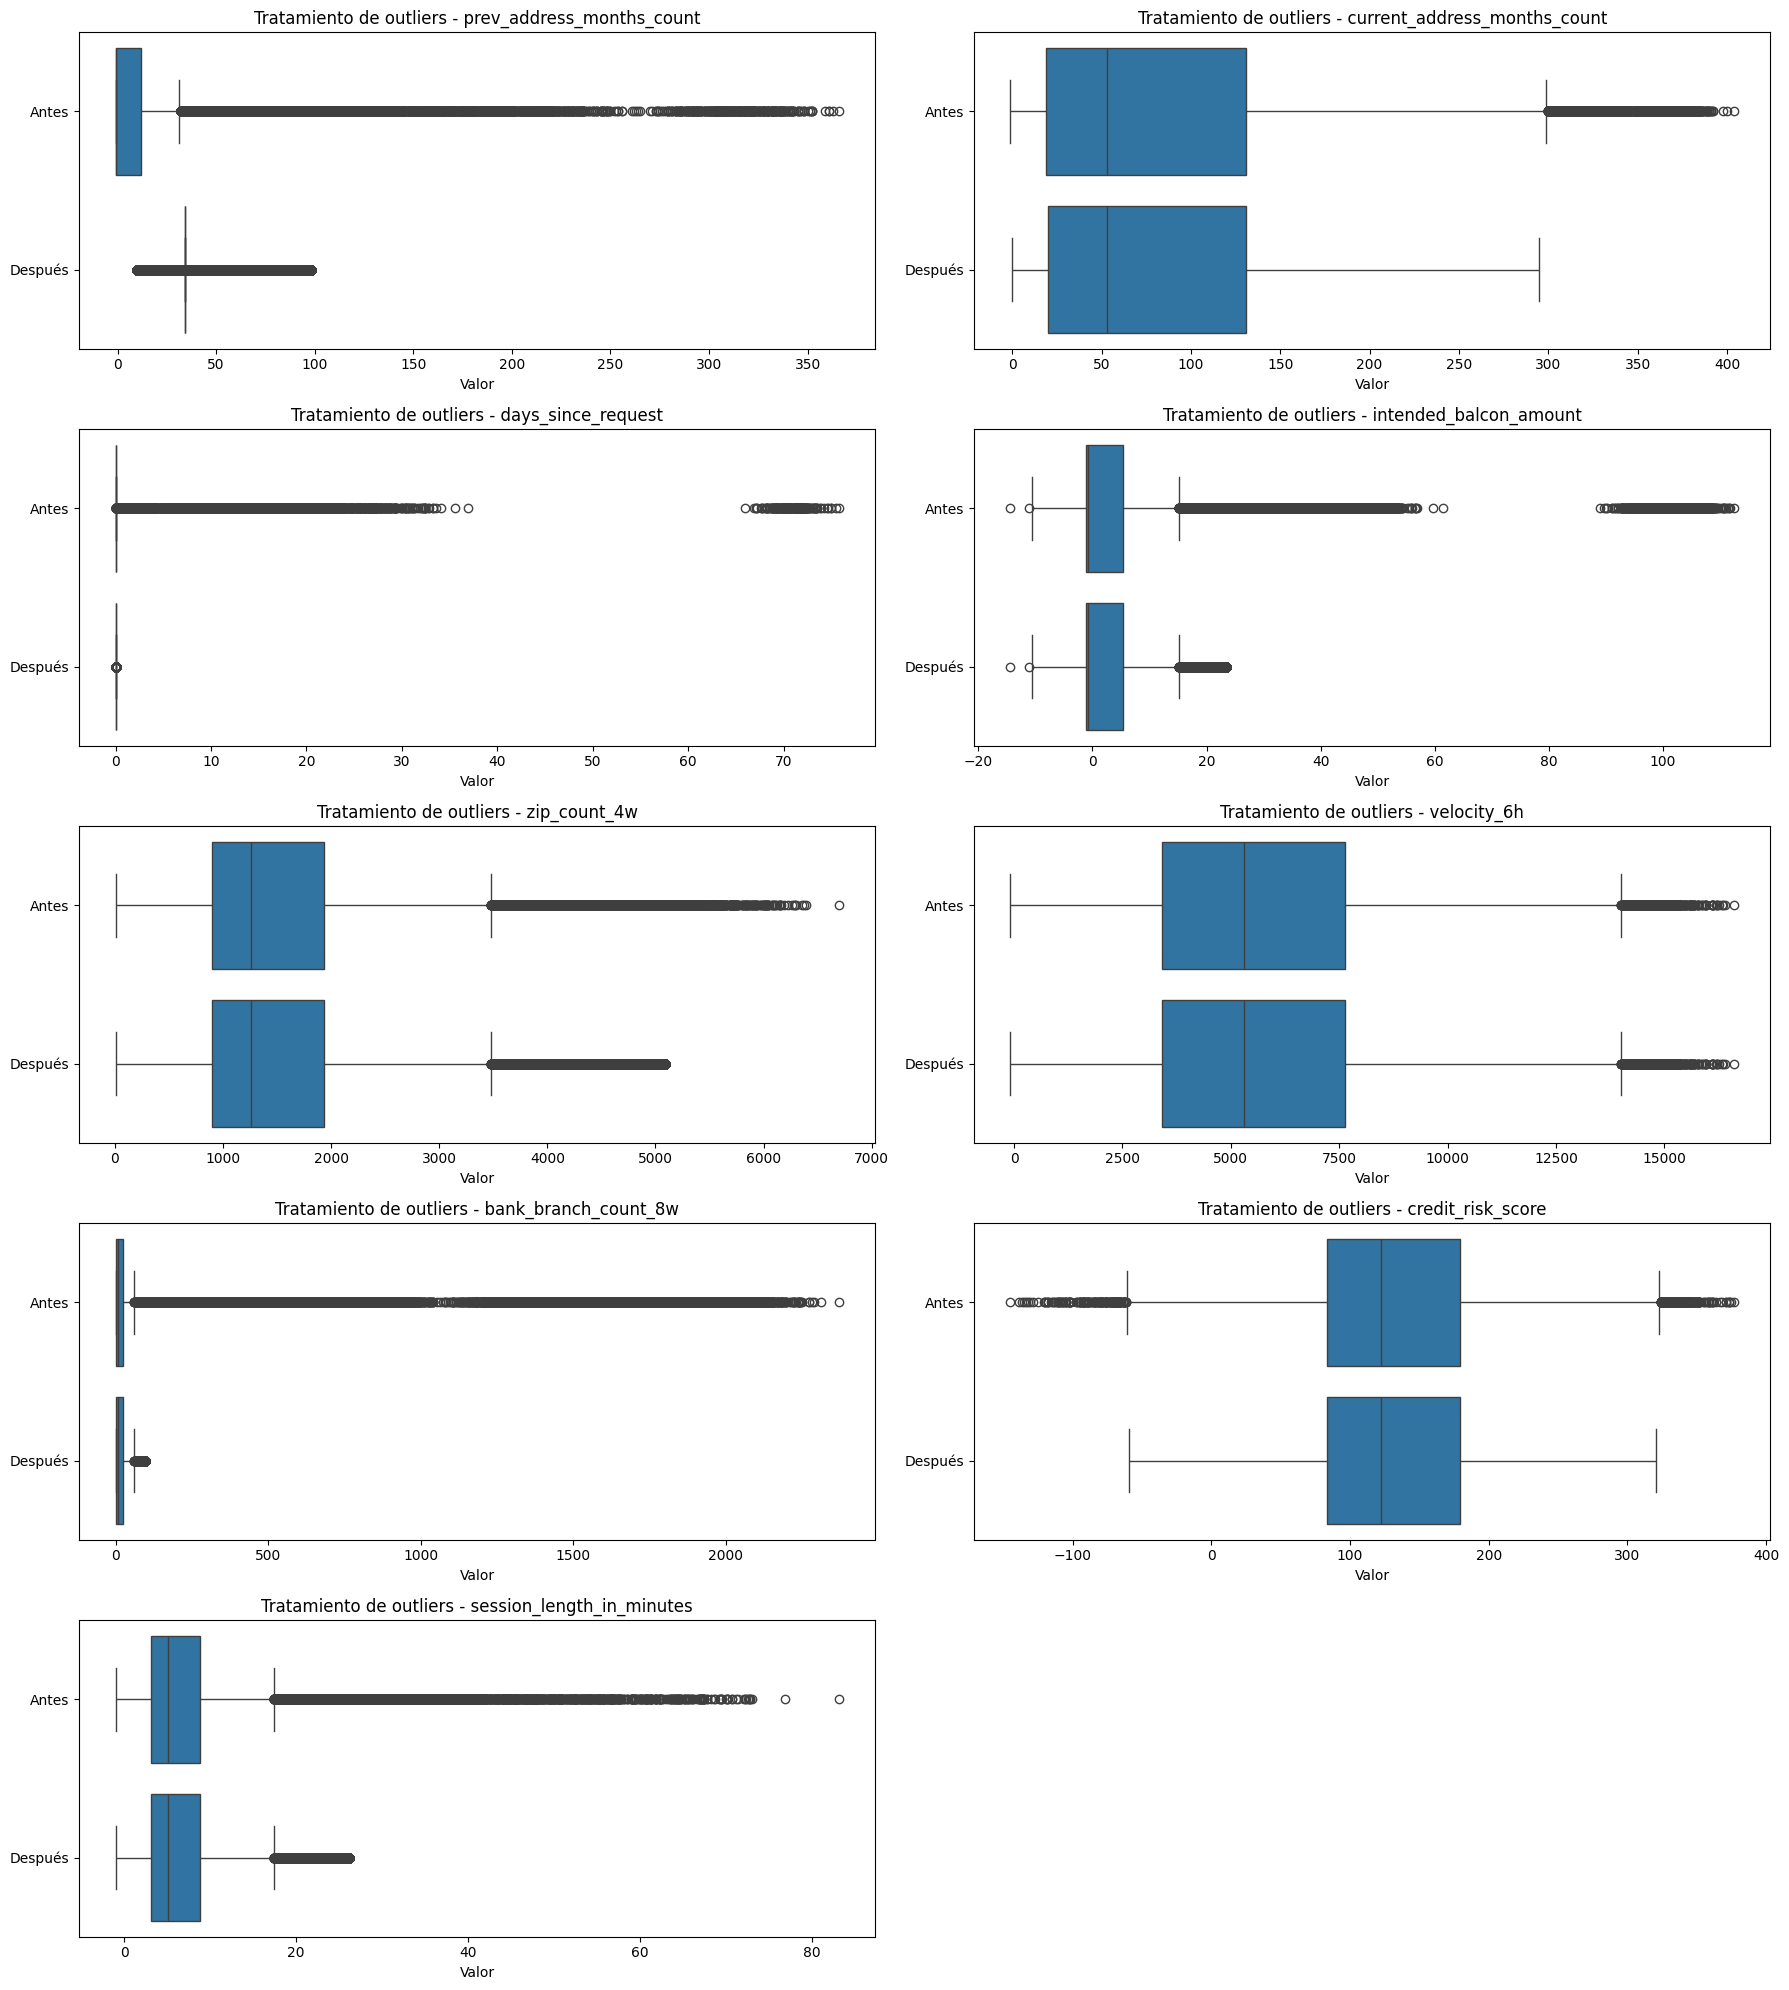

In [10]:
def visualizar_capping_antes_despues(
    X_before: pd.DataFrame,
    X_after: pd.DataFrame,
    columns: list[str],
    sample_size: int = 50_000,
    random_state: int = 42
) -> None:
    """
    Visualiza el efecto del tratamiento mediante boxplots antes/después.
    Se usa una muestra para evitar que el gráfico sea pesado.
    """
    available_cols = [
        col for col in columns
        if col in X_before.columns and col in X_after.columns
    ]

    if len(available_cols) == 0:
        print("No hay columnas disponibles para visualizar.")
        return

    sample_size = min(sample_size, len(X_before))
    sample_index = X_before.sample(
        n=sample_size,
        random_state=random_state
    ).index

    n_cols = 2
    n_rows = int(np.ceil(len(available_cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 4 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(available_cols):
        plot_df = pd.DataFrame({
            "Antes": X_before.loc[sample_index, col],
            "Después": X_after.loc[sample_index, col],
        }).melt(
            var_name="Estado",
            value_name="Valor"
        )

        sns.boxplot(
            data=plot_df,
            x="Valor",
            y="Estado",
            ax=axes[idx]
        )

        axes[idx].set_title(f"Tratamiento de outliers - {col}")
        axes[idx].set_xlabel("Valor")
        axes[idx].set_ylabel("")

    for idx in range(len(available_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig("visualizacion_capping_antes_despues.png")
    plt.show()


cols_visualizar_tratamiento: list[str] = [
    "prev_address_months_count",
    "current_address_months_count",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "bank_branch_count_8w",
    "credit_risk_score",
    "session_length_in_minutes",
]

visualizar_capping_antes_despues(
    X_before=X_train,
    X_after=X_train_out,
    columns=cols_visualizar_tratamiento,
    sample_size=50_000,
    random_state=RANDOM_STATE
)

## 7. Diagnóstico: búsqueda del valor `'CD'`

Celda de diagnóstico que recorre todas las columnas de tipo `object` en `X_train_out` y `X_test_out` buscando el string `'CD'`. Sirve para localizar posibles valores categóricos inesperados que podrían interferir con el escalado posterior.

In [15]:
# DIAGNÓSTICO: Encontrar el string 'CD'

print(" Buscando el string 'CD' en los datos...")

# Buscar en X_train_out
for col in X_train_out.columns:
    if X_train_out[col].dtype == 'object':
        # Verificar si 'CD' está en esta columna
        if 'CD' in X_train_out[col].values:
            print(f"\n ¡ENCONTRADO! Columna: '{col}'")
            print(f"   Valores únicos en esta columna: {X_train_out[col].unique()}")
            print(f"   Tipo de dato: {X_train_out[col].dtype}")
            
            # Mostrar filas donde aparece 'CD'
            mask = X_train_out[col] == 'CD'
            print(f"   Número de filas con 'CD': {mask.sum()}")
            print(f"   Ejemplo de filas con 'CD':")
            print(X_train_out[mask].head(3))

# Buscar también en X_test_out
print(" Buscando en X_test_out...")
for col in X_test_out.columns:
    if X_test_out[col].dtype == 'object':
        if 'CD' in X_test_out[col].values:
            print(f"\n ¡ENCONTRADO! Columna: '{col}'")
            print(f"   Valores únicos: {X_test_out[col].unique()}")

if not any('CD' in str(val) for val in X_train_out.values.ravel() if isinstance(val, str)):
    print("  No se encontró 'CD' en X_train_out")

 Buscando el string 'CD' en los datos...
 Buscando en X_test_out...
  No se encontró 'CD' en X_train_out


## 8. Escalado con `RobustScaler`

`RobustScaler` centra y escala usando la mediana y el IQR, lo que lo hace resistente a los valores extremos que aún puedan quedar tras el capping. Solo se escalan las columnas numéricas; las columnas one-hot (`payment_type_*`, `device_os_*`, `source_*`, `employment_status`, `housing_status`) se excluyen al ser ya binarias.

In [16]:
# Identificar columnas que NO deben escalarse
no_scale_keywords = ['payment_type_', 'device_os_', 'source_', 'employment_status', 'housing_status']

no_scale_cols = []
for col in X_train_out.columns:
    if any(keyword in col for keyword in no_scale_keywords):
        no_scale_cols.append(col)

# El resto (columnas numéricas originales) se escalan
scale_cols = [col for col in X_train_out.columns if col not in no_scale_cols]

print(f"Columnas a escalar: {len(scale_cols)}")
print(f"Columnas a NO escalar: {len(no_scale_cols)}")

# Aplicar scaler
scaler = RobustScaler()
X_train_scaled = X_train_out.copy()
X_test_scaled = X_test_out.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_out[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_out[scale_cols])

Columnas a escalar: 40
Columnas a NO escalar: 21


## 9. Conclusión y exportación

### 9.1 Conclusión del tratamiento


Para el tratamiento de outliers se evitó eliminar observaciones, ya que en detección de fraude los valores extremos pueden representar patrones anómalos relevantes. En primer lugar, los valores `-1` presentes en variables temporales se interpretaron como valores desconocidos y se sustituyeron por la mediana calculada exclusivamente sobre el conjunto de entrenamiento, añadiendo una variable indicadora para conservar dicha información. Posteriormente, se aplicó capping basado en el rango intercuartílico sobre variables continuas con colas largas. Los límites se aprendieron únicamente en el conjunto de entrenamiento y se aplicaron después al conjunto de test, evitando fuga de información. Además, se añadieron variables binarias indicando si cada valor había sido capado, permitiendo al modelo aprovechar la señal asociada a valores extremos sin que estos dominen numéricamente el aprendizaje.

### 9.2 Reunión de los conjuntos escalados

Se concatenan `X_train_scaled` y `X_test_scaled` para reconstruir el dataset completo tratado.

In [17]:
df = pd.concat([X_train_scaled, X_test_scaled], axis=0)

### 9.3 Exportación del dataset final

Se guarda el dataset con outliers tratados y variables escaladas como `base-outliers-tratado.csv`, listo para la siguiente etapa del pipeline.

In [18]:
df.to_csv("base-outliers-tratado.csv", index=False)